In [1]:
import pandas as pd


In [6]:
import pandas as pd

df = pd.read_csv("/content/netflix_titles.csv", encoding='latin1')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8809, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8809 non-null   object
 1   type          8809 non-null   object
 2   title         8809 non-null   object
 3   director      6175 non-null   object
 4   cast          7984 non-null   object
 5   country       7978 non-null   object
 6   date_added    8799 non-null   object
 7   release_year  8809 non-null   int64 
 8   rating        8805 non-null   object
 9   duration      8806 non-null   object
 10  listed_in     8809 non-null   object
 11  description   8809 non-null   object
dtypes: int64(1), object(11)
memory usage: 826.0+ KB


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,release_year
count,8809.000000
mean,2014.181292
std,8.818932
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2024.000000


fill and fix null values


In [65]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [66]:
df['country'] = df['country'].str.split(',').str[0]

In [68]:
df['country'] = df['country'].str.split(',').str[0]

In [70]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [77]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not rated')

df['duration_int'] = df['duration_int'].fillna(df['duration_int'].median())

In [78]:
def categorize(row):
    if row['type'] == 'TV Show':
        return 'TV Show'
    elif row['duration_int'] < 60:
        return 'Short'
    elif row['duration_int'] < 120:
        return 'Medium'
    else:
        return 'Long'

df['content_length_category'] = df.apply(categorize, axis=1)

In [79]:
df['primary_genre'] = df['listed_in'].str.split(',').str[0]

In [90]:
df_original = pd.read_csv("/content/netflix_titles.csv", encoding='latin1')

In [95]:
df['release_year'] = df_original['release_year']

In [96]:
df[['release_year']].head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [97]:
print(df.shape)
print(df.isnull().sum())
df.info()

(8711, 17)
show_id                    0
type                       0
title                      0
director                   0
cast                       0
country                    0
date_added                 0
release_year               0
rating                     0
duration                   0
listed_in                  0
description                0
duration_int               0
content_length_category    0
primary_genre              0
year_added                 0
month_added                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 8711 entries, 0 to 8808
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  8711 non-null   object        
 1   type                     8711 non-null   object        
 2   title                    8711 non-null   object        
 3   director                 8711 non-null   object        
 4   cast      

In [98]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,content_length_category,primary_genre,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,Medium,Documentaries,2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,TV Show,International TV Shows,2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,TV Show,Crime TV Shows,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,TV Show,Docuseries,2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,TV Show,International TV Shows,2021,9


Netflix Content Growth Over Time

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

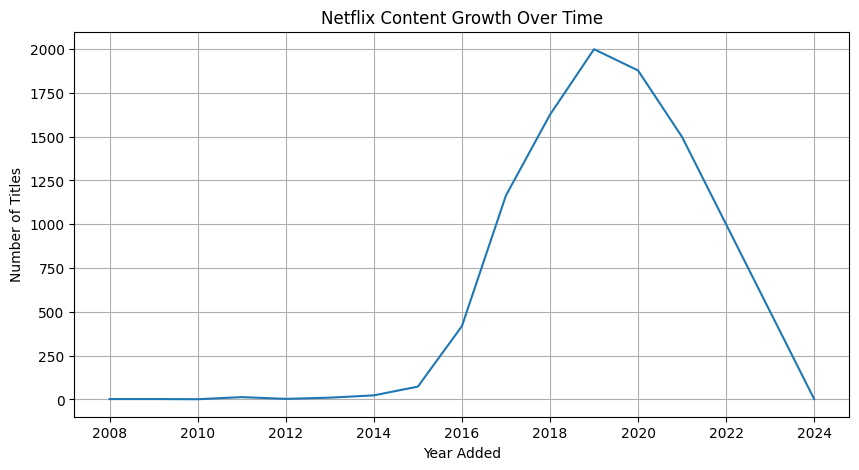

In [100]:
year_growth = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
year_growth.plot()

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.grid()
plt.show()

Content Type Distribution

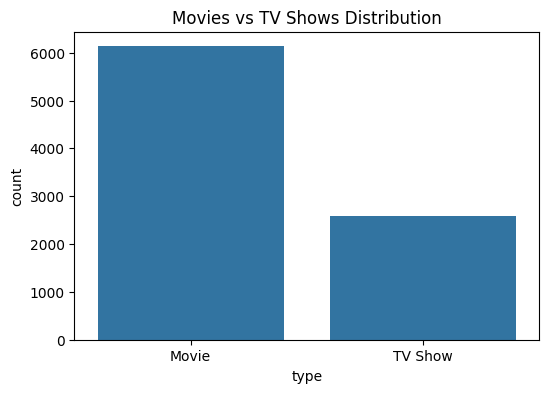

In [101]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows Distribution")
plt.show()

Genre Distribution

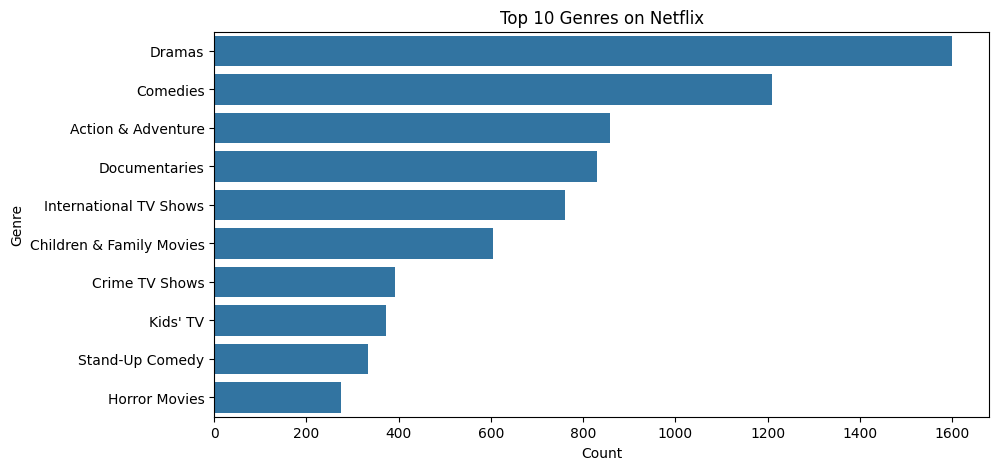

In [102]:
top_genres = df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

Rating Distribution

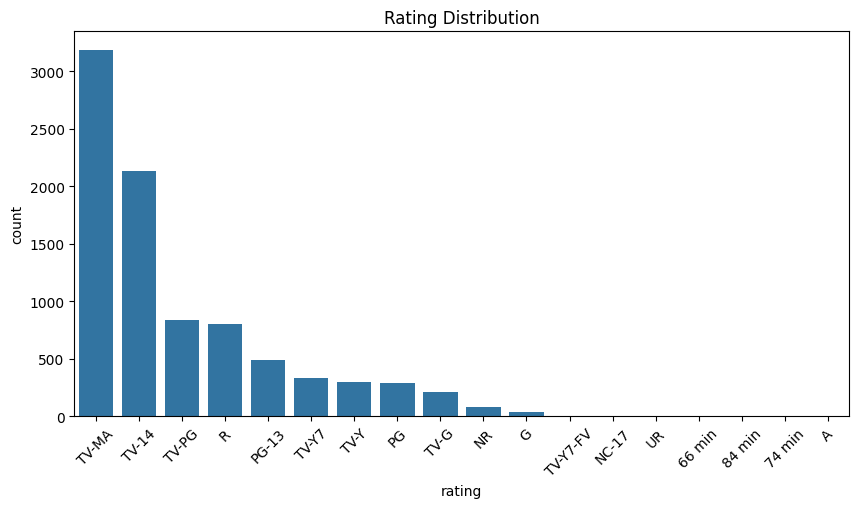

In [103]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Rating Distribution")

plt.show()

Country-Level Contribution

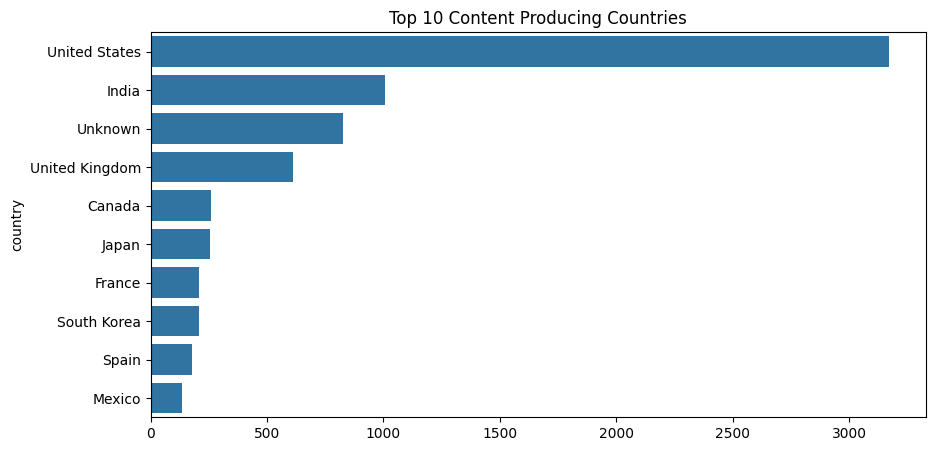

In [104]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Content Producing Countries")

plt.show()

In [105]:
def content_type(row):
    if row['country'] == 'United States' and row['year_added'] >= 2016:
        return 'Original'
    else:
        return 'Licensed'

df['content_origin'] = df.apply(content_type, axis=1)

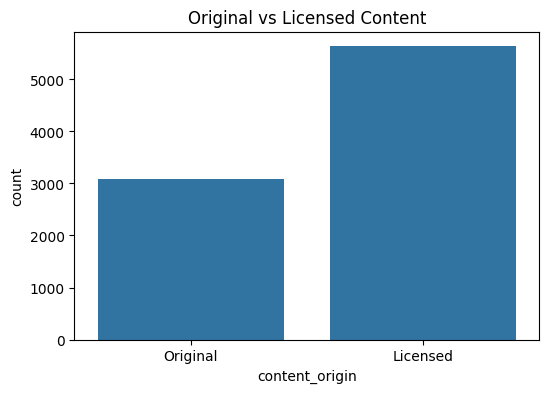

In [106]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='content_origin')

plt.title("Original vs Licensed Content")

plt.show()

In [107]:
#Feature Engineering

In [108]:
cluster_df = df[['duration_int','release_year','primary_genre','rating']]

cluster_df = pd.get_dummies(cluster_df, drop_first=True)

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

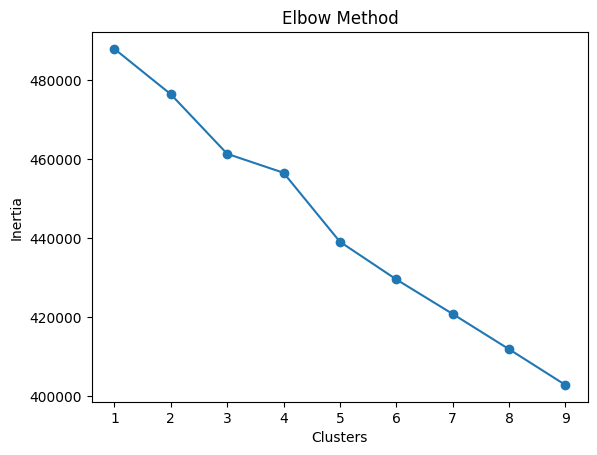

In [110]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [111]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

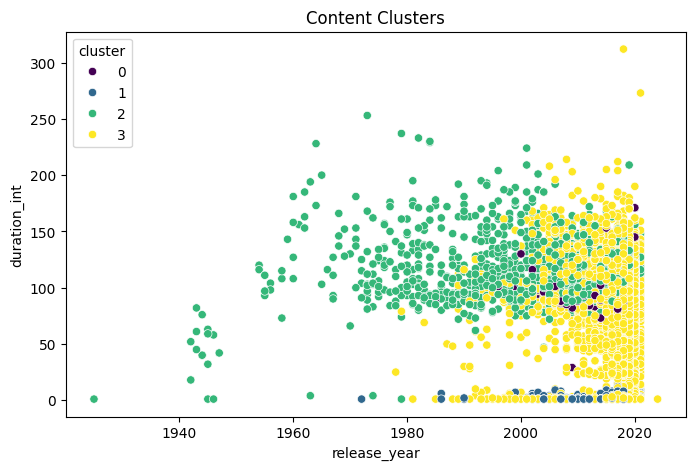

In [112]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['release_year'],
    y=df['duration_int'],
    hue=df['cluster'],
    palette='viridis'
)

plt.title("Content Clusters")
plt.show()

In [113]:
ml_df = df[['type','duration_int','release_year','primary_genre','rating','country']]

ml_df = pd.get_dummies(ml_df, drop_first=True)

X = ml_df.drop('type_TV Show', axis=1)
y = ml_df['type_TV Show']

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [115]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [116]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9994262765347103
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1223
        True       1.00      1.00      1.00       520

    accuracy                           1.00      1743
   macro avg       1.00      1.00      1.00      1743
weighted avg       1.00      1.00      1.00      1743



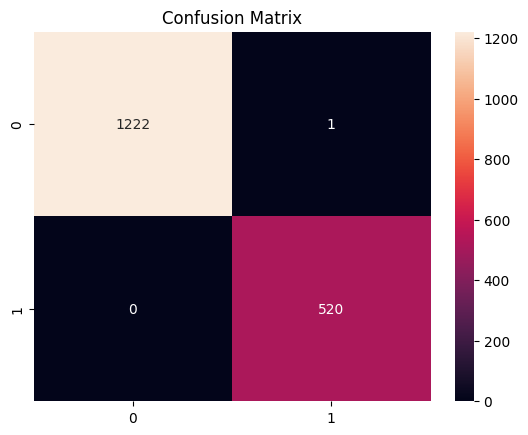

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

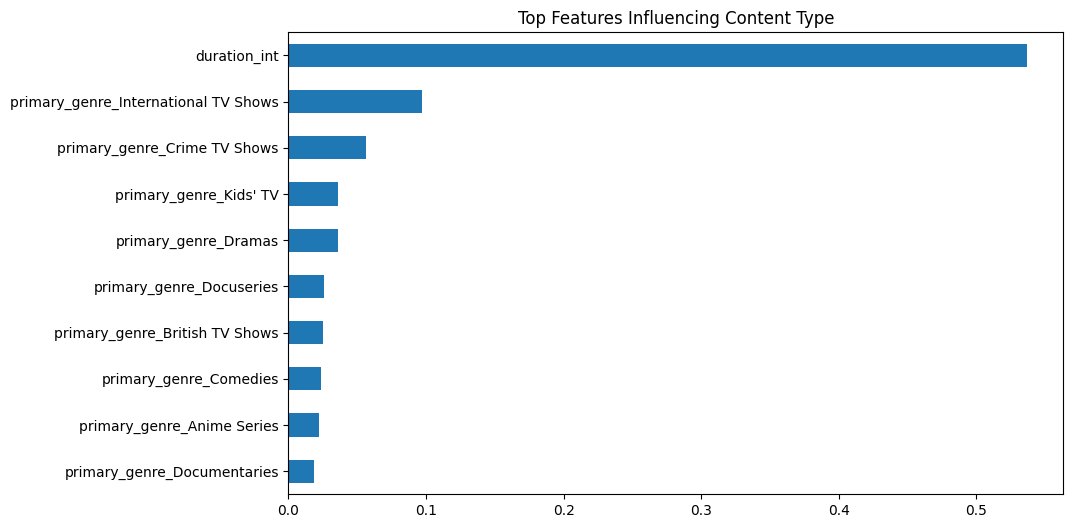

In [118]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().tail(10).plot(kind='barh', figsize=(10,6))

plt.title("Top Features Influencing Content Type")
plt.show()

In [119]:
pd.crosstab(df['country'], df['primary_genre']).head()

primary_genre,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,2,0,0,0,2,1,1,9,7,0,...,0,8,0,0,0,0,0,0,0,0
Australia,8,0,0,2,14,0,3,3,7,0,...,0,3,0,0,3,1,0,0,0,1
Austria,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
top_countries = df['country'].value_counts().head(5).index
top_genres = df['primary_genre'].value_counts().head(8).index

filtered = df[
    (df['country'].isin(top_countries)) &
    (df['primary_genre'].isin(top_genres))
]

In [122]:
genre_country = filtered.groupby(['primary_genre','country']).size().unstack().fillna(0)

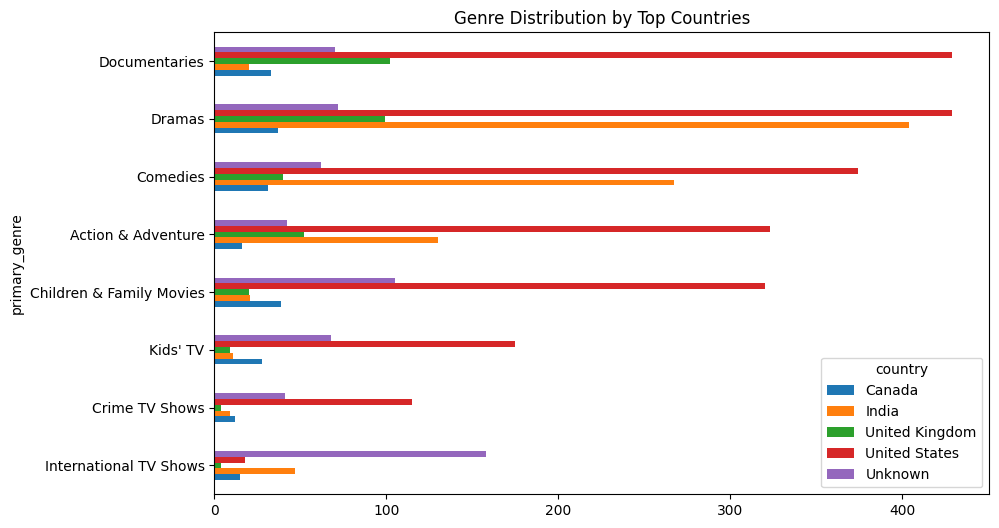

In [124]:
genre_country = genre_country.sort_values(by=top_countries[0], ascending=True)

genre_country.plot(kind='barh', figsize=(10,6))
plt.title("Genre Distribution by Top Countries")
plt.show()